# Сравнение субквадратичных вниманий: Linformer / Linear / Reformer / Performer

Репликация четырёх семейств линейного/сублинейного внимания на одном стенде:

- **Linformer** — Wang et al., *Linformer: Self-Attention with Linear Complexity* (arXiv:2006.04768): low-rank проекция K/V с `n` на `k` токенов по seq-измерению → O(nk).
- **Linear Transformer** — Katharopoulos et al., *Transformers are RNNs* (arXiv:2006.16236): ядро `φ(Q)·φ(K)` с φ=elu+1, KV-продукт O(d²), не зависящий от `n` → O(n).
- **Reformer** — Kitaev et al. (arXiv:2001.04451): LSH-хэширование группирует ключи в бакеты, каждый запрос смотрит только в своё окно `2·bucket_size` → O(n log n) (сортировка доминирует).
- **Performer** — Choromanski et al. (arXiv:2009.14794): FAVOR+, мягкое ядро с положительными ортогональными рандом-фичами, KV-продукт O(m·d) не зависит от `n` → O(n·m).

Все четыре — слои библиотеки: `spartan_torch.LinformerAttention`, `spartan_torch.LinearTransformerAttention`, `spartan_torch.ReformerAttention`, `spartan_torch.PerformerAttention`. Базовая линия — `spartan_torch.MultiHeadAttention` в двух режимах: классический (`use_sdpa=False`, материализует n×n скоры) и `use_sdpa=True` (SDPA/FlashAttention).

Бенчмарк bidirectional для всех (Linear/Reformer/Performer с `is_causal=False`): замеряем именно сложность, а не маскировку.

> Считать на GPU (CUDA). На CPU при больших `seq_len` MHA упадёт по памяти — бенчмарк тогда честен только до ~2048 токенов.


In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from spartan_torch import (
    LinearTransformerAttention,
    LinformerAttention,
    MultiHeadAttention,
    PerformerAttention,
    ReformerAttention,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {DEVICE}")

# --- общий конфиг ---
D = 512  # d_model
H = 8  # heads
HS = D // H  # head_size = 64
SEQ_LENS = [512, 1024, 2048, 4096, 8192, 16384]
BATCH = 1
WARMUP, REPS = 2, 3

# --- конфиг Linformer: проекция n -> k (в бумаге для n=512) ---
K = 128
SHARING = "layerwise"  # бумага: layerwise шеринг дал лучший результат

# --- конфиг Reformer (дефолты бумаги) ---
N_HASHES = 8
BUCKET_SIZE = 64
N_BUCKETS = 128

torch.manual_seed(0)
torch.set_float32_matmul_precision("medium")


torch 2.13.0+cu132 | device: cuda


In [2]:
def make_linformer():
    return LinformerAttention(
        D, HS, H, D,
        proj_k=K, max_seq_len=max(SEQ_LENS), sharing=SHARING,
    ).to(DEVICE)

def make_linear():
    # bidirectional (is_causal=False дефолт): KV-продукт O(d^2), не зависит от n
    return LinearTransformerAttention(D, HS, H, D).to(DEVICE)

def make_reformer():
    # окно 2*bucket_size на запрос; is_causal=False — чистая сложность
    return ReformerAttention(
        D, HS, H, D,
        n_hashes=N_HASHES, bucket_size=BUCKET_SIZE, n_buckets=N_BUCKETS,
        is_causal=False,
    ).to(DEVICE)

def make_performer():
    # FAVOR+ ORF-фичи; num_features=дефолт m=int(64*log(64))=266, O(n*m)
    return PerformerAttention(D, HS, H, D).to(DEVICE)

def make_mha_sdpa():
    # практический baseline: SDPA/FlashAttention не материализует n x n скоры
    return MultiHeadAttention(D, HS, H, D, use_sdpa=True).to(DEVICE)

def make_mha_manual():
    # классическое квадратичное внимание: материализует n x n скоры ->
    # квадратичные время и память (то, с чем эффективные слои сравниваются)
    return MultiHeadAttention(D, HS, H, D, use_sdpa=False).to(DEVICE)


In [3]:
def forward(model, x):
    """Unwrap MHA's (output, cache) tuple."""
    out = model(x, x, x)
    return out[0] if isinstance(out, tuple) else out


def bench(model, seq_len):
    """Mean forward+backward time and peak CUDA memory for one seq_len."""
    x = torch.randn(BATCH, seq_len, D, device=DEVICE)
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    for _ in range(WARMUP):
        loss = forward(model, x).square().mean()
        loss.backward()
    model.zero_grad(set_to_none=True)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(REPS):
        loss = forward(model, x).square().mean()
        loss.backward()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = (time.perf_counter() - t0) / REPS
    mem = torch.cuda.max_memory_allocated() if DEVICE == "cuda" else float("nan")
    return dt, mem


## Замеры

Каждая точка — forward+backward, среднее по `REPS` после `WARMUP` прогрева. Память — пиковый аллокатор CUDA на весь прогон модели при одном `seq_len`. Если модель ловит OOM на больших `n` — точка пропускается.


In [4]:
models = {
    "Linformer (k=128)": make_linformer(),
    "Linear (feature map)": make_linear(),
    "Reformer (LSH)": make_reformer(),
    "Performer (FAVOR+)": make_performer(),
    "MHA (SDPA)": make_mha_sdpa(),
    "MHA (manual n^2)": make_mha_manual(),
}

results = {}
for name, model in models.items():
    results[name] = {}
    for n in SEQ_LENS:
        try:
            results[name][n] = bench(model, n)
            print(f"{name:20s} n={n:>6} done")
        except RuntimeError as e:
            results[name][n] = None
            print(f"{name:20s} n={n:>6} SKIPPED ({type(e).__name__})")


Linformer (k=128)    n=   512 done
Linformer (k=128)    n=  1024 done
Linformer (k=128)    n=  2048 done
Linformer (k=128)    n=  4096 done
Linformer (k=128)    n=  8192 done


Linformer (k=128)    n= 16384 done
Linear (feature map) n=   512 done
Linear (feature map) n=  1024 done
Linear (feature map) n=  2048 done
Linear (feature map) n=  4096 done


Linear (feature map) n=  8192 done
Linear (feature map) n= 16384 done


Reformer (LSH)       n=   512 done
Reformer (LSH)       n=  1024 done


Reformer (LSH)       n=  2048 done


...

MHA (SDPA)           n= 16384 done
MHA (manual n^2)     n=   512 done
MHA (manual n^2)     n=  1024 done


MHA (manual n^2)     n=  2048 done


MHA (manual n^2)     n=  4096 done


MHA (manual n^2)     n=  8192 done


MHA (manual n^2)     n= 16384 SKIPPED (OutOfMemoryError)


In [5]:
print(f"{'model':20s} {'n':>7s} {'time':>12s} {'peak_mem':>12s}")
for name, res in results.items():
    for n in SEQ_LENS:
        if res[n] is None:
            print(f"{name:20s} {n:>7d}     OOM/skip")
        else:
            dt, mem = res[n]
            if mem != mem:
                print(f"{name:20s} {n:>7d} {dt * 1e3:9.2f} ms       (cpu)")
            else:
                print(f"{name:20s} {n:>7d} {dt * 1e3:9.2f} ms {mem / 2**20:10.1f} MiB")


model                      n         time     peak_mem
Linformer (k=128)        512      3.96 ms       80.7 MiB
Linformer (k=128)       1024      3.06 ms       85.0 MiB
Linformer (k=128)       2048      5.33 ms      109.0 MiB
Linformer (k=128)       4096      8.66 ms      157.0 MiB
Linformer (k=128)       8192     15.52 ms      253.0 MiB
Linformer (k=128)      16384     30.03 ms      445.0 MiB
Linear (feature map)     512      5.29 ms       77.6 MiB
Linear (feature map)    1024      4.72 ms       90.6 MiB
Linear (feature map)    2048      4.54 ms      116.6 MiB
Linear (feature map)    4096      7.59 ms      168.7 MiB
Linear (feature map)    8192     13.55 ms      272.8 MiB
Linear (feature map)   16384     31.82 ms      481.1 MiB
Reformer (LSH)           512     13.72 ms      240.1 MiB
Reformer (LSH)          1024     27.29 ms      412.6 MiB
Reformer (LSH)          2048     52.90 ms      757.7 MiB
Reformer (LSH)          4096    109.68 ms     1447.8 MiB
Reformer (LSH)          8192   14

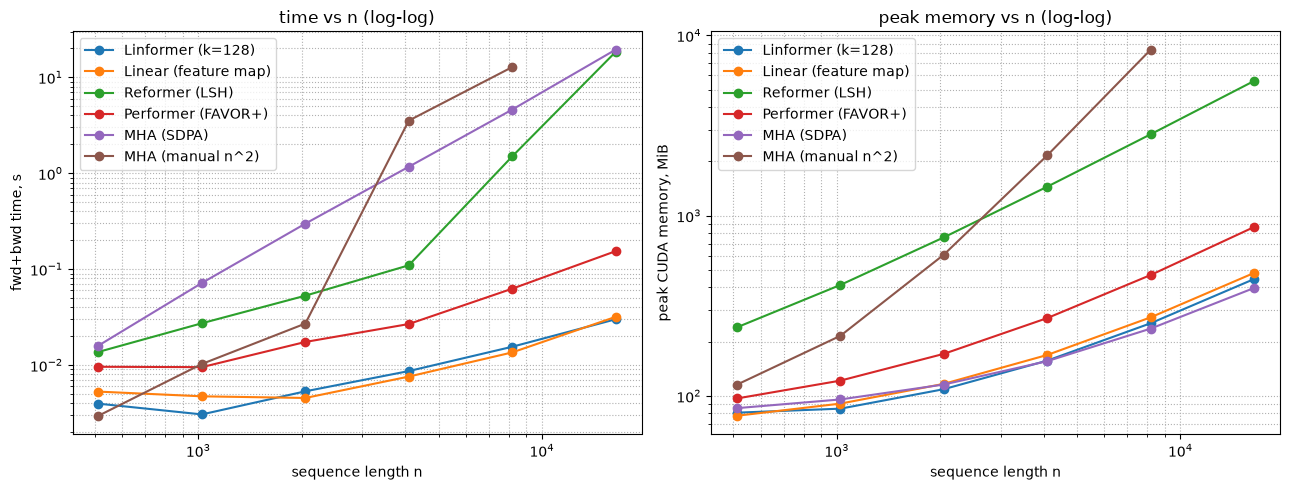

model                time-slope  mem-slope
Linformer (k=128)         0.64       0.50
Linear (feature map)      0.52       0.53
Reformer (LSH)            2.01       0.91
Performer (FAVOR+)        0.82       0.64
MHA (SDPA)                2.03       0.44
MHA (manual n^2)          3.26       1.57


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, res in results.items():
    ns = np.array([n for n in SEQ_LENS if res[n] is not None], dtype=float)
    if len(ns) == 0:
        continue
    times = np.array([res[n][0] for n in ns])
    mems = np.array([res[n][1] / 2**20 for n in ns])
    axes[0].loglog(ns, times, marker="o", label=name)
    axes[1].loglog(ns, mems, marker="o", label=name)
axes[0].set_xlabel("sequence length n")
axes[0].set_ylabel("fwd+bwd time, s")
axes[0].set_title("time vs n (log-log)")
axes[0].grid(True, which="both", ls=":")
axes[1].set_xlabel("sequence length n")
axes[1].set_ylabel("peak CUDA memory, MiB")
axes[1].set_title("peak memory vs n (log-log)")
axes[1].grid(True, which="both", ls=":")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

# --- наклон кривых: 2 = квадратично, 1 = линейно ---
print(f"{'model':20s} time-slope  mem-slope")
for name, res in results.items():
    ns = np.array([n for n in SEQ_LENS if res[n] is not None], dtype=float)
    if len(ns) < 3:
        print(f"{name:20s}     (недостаточно точек)")
        continue
    times = np.array([res[n][0] for n in ns])
    mems = np.array([res[n][1] for n in ns])
    st = np.polyfit(np.log10(ns), np.log10(times), 1)[0]
    sm = np.polyfit(np.log10(ns), np.log10(mems), 1)[0]
    print(f"{name:20s} {st:9.2f}  {sm:9.2f}")


## Ожидаемый результат

- `MHA (manual n^2)`: наклон ~**2** и по времени, и по памяти — классическое квадратичное внимание, на больших `n` упирается в память (n×n скоры) и пропускается.
- `MHA (SDPA)`: наклон по времени ~**2** (чуть меньше из-за fused-бэкендов), но память почти линейная — FlashAttention не материализует скоры.
- `Linformer (k=128)`: наклон ~**1** по времени и памяти (в идеале чуть меньше — доминируют линейные Q/K/V-проекции).
- `Linear (feature map)`: наклон ~**1** по времени, память почти **плоская** — KV-продукт размера d×d не зависит от `n`. Самая быстрая на больших `n`: на каждый токен только линейные проекции.
- `Performer (FAVOR+)`: наклон ~**1** по времени и памяти — KV-продукт размера m×d (m = число фич) не зависит от `n`. Медленнее Linear из-за более тяжёлого ядра: `m ≈ d·log d` фич против `elu(x)+1`.
- `Reformer (LSH)`: время растёт чуть быстрее линейного (**сортировка O(n log n)**) и с большим константным множителем из-за `n_hashes` раундов хэширования; память линейная — фиксированное окно `2·bucket_size` на запрос. На малых `n` проигрывает остальным (оверхед хэшей), выгода — при больших `n`.

Опорные цифры бумаг (V100): Linformer при n=65536, k=128 — ~**20×** быстрее и ~**60×** меньше памяти, чем стандартный transformer; Linear Transformer — O(n) время и O(1) память (по seq); Reformer — 12 слоёв на 1M-токенах на одном чипе (64 GB TPU); Performer — доступен при 1M-токенах в ~**10×** быстрее, чем standard attention (производственная версия).